**Projet 9 - Analyser les ventes d'une librairie avec R ou Python**

Nous devons établir les solutions suivantes pour avoir une compte rendu cohérent :

Une partie sur les profils des acheteurs qui sera comparé à divers critères :     



1.   Genre d'un client vs Catégories de livres achetés
2.   Lien entre l'âge des clients et :    

*   Montant total des achats
*   Fréquence d'achats
*   Taille moyen du panier
*   Catégorie de livres achetés

**Par la suite, nous allons également nous intéresser à plusieurs crtières de vente**



1.   Evolution du Chiffre d'affaire #GRAPHIQUE
2.   Décomposition en moyenne mobiles de la série
3.   Courbe de Lorenz pour la dispersion des clients
4.   Et tout autre analyse complémentaire permettant une meilleure compréhension du business et ou des ventes en général+ Comportement client








In [1]:
#Importation des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy as sp



1. Chargements des fichiers
---



In [2]:
#Importation du fichier customers.csv
df_customers = pd.read_csv("customers.csv", sep=";")

#Importation du fichier products.csv
df_products = pd.read_csv("products.csv", sep=";")

#importation du fichier Transactions.csv
df_transactions = pd.read_csv("Transactions.csv", sep=";")

/tmp/ipykernel_3584/2731567687.py:8: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("Transactions.csv", sep=";")


1.2 - Analyse exploratoire des fichiers

Objectifs :  vérifier la structure des fichiers et detecter les anomalies.

1.2.1 - Analyse exploratoire du fichier product.csv

In [3]:
#Dimension du dataset
#Affichage des premières lignes du dataset
#Information du fichier product
#Detection de doublons
#Detection des valeurs uniques

print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("\nLe tableau comporte {} colonne(s)".format(df_products.shape[1]))

print("Les 5 premières lignes de la table PRODUCTS :\n")
display(df_products.head())

print("\nInformations sur la table PRODUCTS :\n")
df_products.info()

Le tableau comporte 3286 observation(s) ou article(s)

Le tableau comporte 3 colonne(s)
Les 5 premières lignes de la table PRODUCTS :



,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0



Informations sur la table PRODUCTS :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [4]:
print("Valeurs manquantes :\n")
print(df_products.isnull().sum())

Valeurs manquantes :

id_prod    0
price      0
categ      0
dtype: int64


In [5]:
print("Lignes comportant des doublons :")
print(df_products.duplicated().sum())

Lignes comportant des doublons :
0


In [6]:
# Produits uniques
print("Nombre total de produits :", df_products.shape[0])
print("\nNombre d'identifiants produits uniques :", df_products['id_prod'].nunique())

print("\nStatistiques descriptives sur les prix :")
print(df_products['price'].describe(), round(2))

print("\nRépartition des produits par catégorie :")
print(df_products['categ'].value_counts())

Nombre total de produits : 3286

Nombre d'identifiants produits uniques : 3286

Statistiques descriptives sur les prix :
count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64 2

Répartition des produits par catégorie :
categ
0    2308
1     739
2     239
Name: count, dtype: int64


In [7]:
#Utilisation des valeurs IQR pour detection des outliers :

Q1_price = df_products['price'].quantile(0.25)
Q3_price = df_products['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

borne_basse_price = Q1_price - 1.5 * IQR_price
borne_haute_price = Q3_price + 1.5 * IQR_price

print(f"Borne basse : {borne_basse_price:.2f} €")
print(f"Borne haute : {borne_haute_price:.2f} €")

outliers_price = df_products[
    (df_products['price'] < borne_basse_price) |
    (df_products['price'] > borne_haute_price)
]

print(f"\nNombre de produits considérés comme outliers : {outliers_price.shape[0]}")
print("\nExemples de valeurs aberrantes :")
display(outliers_price.sort_values(by='price', ascending=False).head())


Borne basse : -17.01 €
Borne haute : 46.99 €

Nombre de produits considérés comme outliers : 302

Exemples de valeurs aberrantes :


,id_prod,price,categ
946,2_2,300.00,2
724,2_76,254.44,2
394,2_158,247.22,2
1435,2_167,236.99,2
2778,2_30,233.54,2


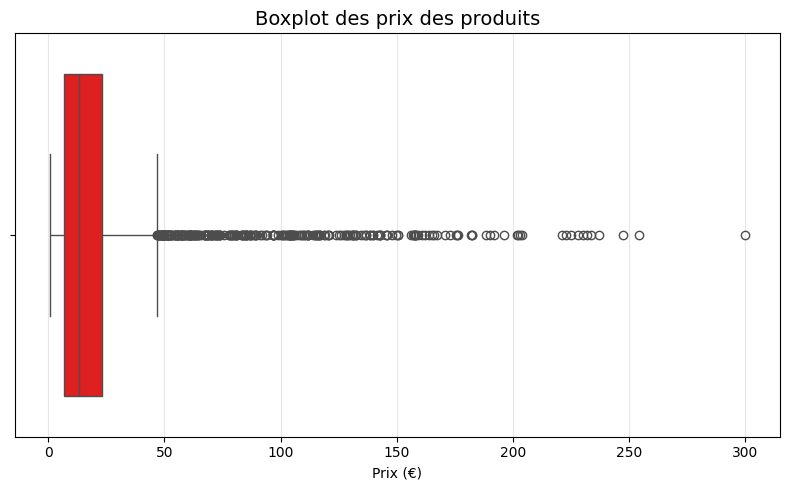

In [8]:
#Boxplot des prix des produits

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_products['price'], color='red')

plt.title("Boxplot des prix des produits", fontsize=14)
plt.xlabel("Prix (€)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.show()

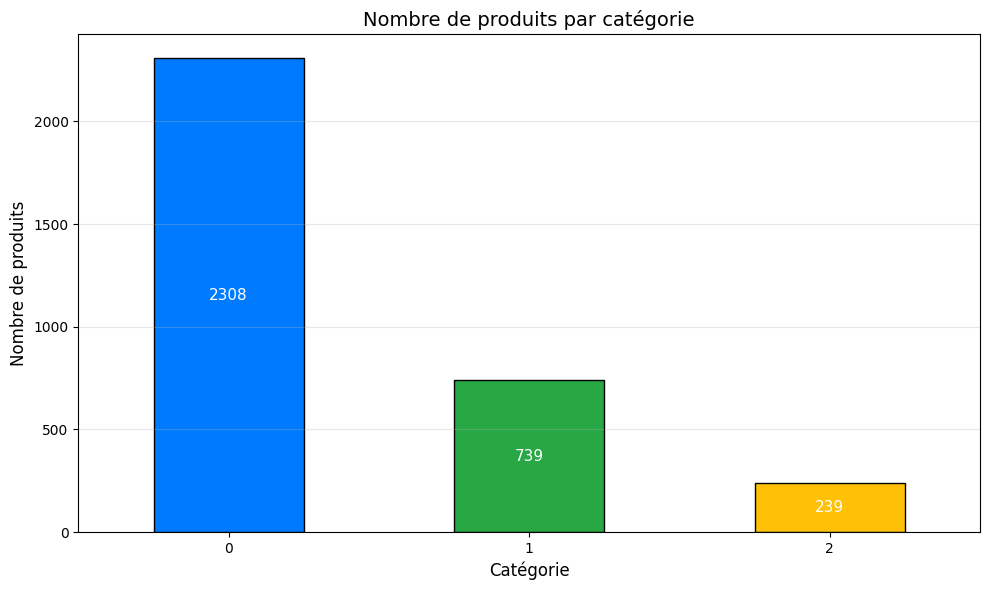

In [9]:
# Visualisation via un graphique à barres pour comparer les types de produits par catégorie


produits_par_categorie = df_products['categ'].value_counts().sort_index()
couleurs = ['#007bff', '#28a745', '#ffc107']

# Création des graphiques
plt.figure(figsize=(10, 6))
bars = produits_par_categorie.plot(kind='bar', color=couleurs, edgecolor='black')

# Ajout des valeurs à l’intérieur des barres
for i, val in enumerate(produits_par_categorie):
    bars.text(i, val / 2, str(val), ha='center', va='center', fontsize=11, color='white')

# Mise en forme du graphique
plt.title('Nombre de produits par catégorie', fontsize=14)
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel('Nombre de produits', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

1.3 - ANalyse exploratoire du fichier Transaction.csv

Objectifs :  vérifier la structure des fichiers et detecter les anomalies.

In [10]:
#Dimension du dataset
#Affichage des premières lignes du dataset
#Information du fichier product
#Detection de doublons
#Detection des valeurs uniques

print(f"Le tableau comporte {df_transactions.shape[0]} observations")
print(f"Le tableau comporte {df_transactions.shape[1]} colonnes\n")
print("Les 5 premières lignes de la table TRANSACTIONS :")
display(df_transactions.head())




Le tableau comporte 1048575 observations
Le tableau comporte 4 colonnes

Les 5 premières lignes de la table TRANSACTIONS :


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [11]:
print("Informations sur df_transactions :")
df_transactions.info()

print("\nValeurs manquantes par colonne :")
print(df_transactions.isnull().sum())

print("\nNombre de doublons :")
print(df_transactions.duplicated().sum())

Informations sur df_transactions :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB

Valeurs manquantes par colonne :
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

Nombre de doublons :
361040


In [12]:
print(df_transactions)

        id_prod                        date session_id client_id
0        0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1        0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2        0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3        0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4        0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
...         ...                         ...        ...       ...
1048570     NaN                         NaN        NaN       NaN
1048571     NaN                         NaN        NaN       NaN
1048572     NaN                         NaN        NaN       NaN
1048573     NaN                         NaN        NaN       NaN
1048574     NaN                         NaN        NaN       NaN

[1048575 rows x 4 columns]


In [13]:
df_transactions.dropna(inplace=True)

print("Post-suppression des lignes vides :")
print(f"\nNombre d'observations restantes : {df_transactions.shape[0]}")
print("\nValeurs manquantes restantes par colonnes :")
print(df_transactions.isnull().sum())

Post-suppression des lignes vides :

Nombre d'observations restantes : 687534

Valeurs manquantes restantes par colonnes :
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


In [14]:
print(df_transactions)

       id_prod                        date session_id client_id
0       0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1       0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2       0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3       0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4       0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
...        ...                         ...        ...       ...
687529   1_508  2023-02-28 23:49:03.148402   s_348444    c_3573
687530    2_37  2023-02-28 23:51:29.318531   s_348445      c_50
687531   1_695  2023-02-28 23:53:18.929676   s_348446     c_488
687532  0_1547  2023-02-28 23:58:00.107815   s_348447    c_4848
687533  0_1398  2023-02-28 23:58:30.792755   s_348435    c_3575

[687534 rows x 4 columns]


In [15]:
#Vérification des élémentss uniques du Dataframe

print("Nombre de produits uniques :", df_transactions['id_prod'].nunique())
print("Nombre de clients uniques :", df_transactions['client_id'].nunique())
print("Nombre de sessions uniques :", df_transactions['session_id'].nunique())




Nombre de produits uniques : 3265
Nombre de clients uniques : 8600
Nombre de sessions uniques : 345505


In [16]:
#Uniformisation des colonnes

df_transactions['date'] = pd.to_datetime(df_transactions['date'])
print("Période couverte :", df_transactions['date'].min(), "→", df_transactions['date'].max())

df_transactions['year'] = df_transactions['date'].dt.year
print("\nNombre de transactions par année :")
print(df_transactions['year'].value_counts().sort_index())

Période couverte : 2021-03-01 00:01:07.843138 → 2023-02-28 23:58:30.792755

Nombre de transactions par année :
year
2021    286671
2022    346380
2023     54483
Name: count, dtype: int64


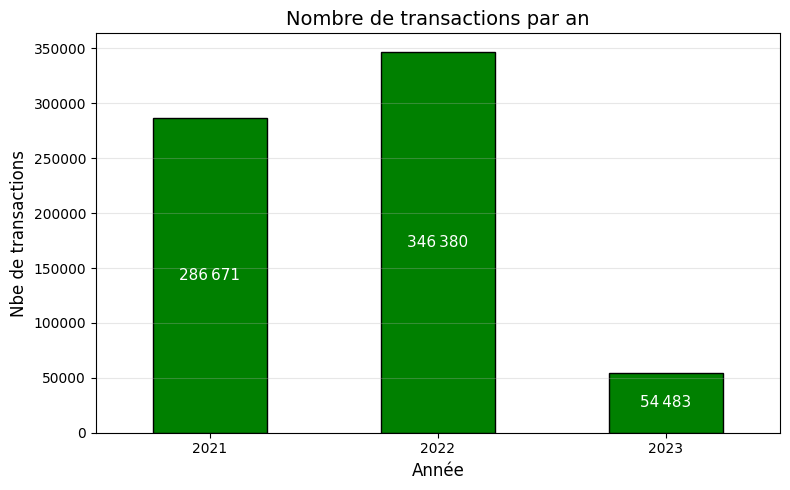

In [17]:
#Graphique pouvant indiquer le nombre de transaction réalisées par an.

transactions_par_annee = df_transactions['year'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
bars = transactions_par_annee.plot(kind='bar', color='green', edgecolor='black')

for i, val in enumerate(transactions_par_annee):
    bars.text(i, val / 2, f"{val:,}".replace(",", "\u202f"), ha='center', va='center', color='white', fontsize=11)

#Mise en forme du graphique :

    plt.title("Nombre de transactions par an", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nbe de transactions", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

2.1 - Analyse exploratoire du fichier customer.csv

Objectifs :  vérifier la structure des fichiers et detecter les anomalies.

Client ID : pour les ID clients
Sex : pour le genre des clients
Birth : pour l'année de naissance des clients

In [18]:
#Dimension du dataset
#Affichage des premières lignes du dataset
#Information du fichier product
#Detection de doublons
#Detection des valeurs uniques

print(f"Le tableau comporte {df_customers.shape[0]} observations")
print(f"Le tableau comporte {df_customers.shape[1]} colonnes\n")

print("Les 5 premières lignes :")
display(df_customers.head())

print("\nInformations CUSTOMER csv:")
df_customers.info()

Le tableau comporte 8621 observations
Le tableau comporte 3 colonnes

Les 5 premières lignes :


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943



Informations CUSTOMER csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [19]:
#Vérification des doublons dans le dataset

print("\nValeurs manquantes :")
print(df_customers.isnull().sum())

print("\nNombre de doublons :")
print(df_customers.duplicated().sum())




Valeurs manquantes :
client_id    0
sex          0
birth        0
dtype: int64

Nombre de doublons :
0


2.2 - Classification, proportion par genre des clients dans le dataset

In [20]:
#Proportion par genre et répartition du nombre de clients (F & M) dans le dataset

print("Répartition du nombre de clients par genre :")
print(df_customers['sex'].value_counts().apply(lambda x: f"{x:,}".replace(",", "\u202f")))
print("\nRépartition en proportion :")
print((df_customers['sex'].value_counts(normalize=True) * 100).round(2))


Répartition du nombre de clients par genre :
sex
f    4 490
m    4 131
Name: count, dtype: object

Répartition en proportion :
sex
f    52.08
m    47.92
Name: proportion, dtype: float64


In [21]:
#Répartition et analyse de l'âge de la population du dataset

df_customers['age'] = 2023 - df_customers['birth']
print("Statistiques sur l'âge des clients :")
print(df_customers['age'].describe().round(1))

Statistiques sur l'âge des clients :
count    8621.0
mean       44.7
std        16.9
min        19.0
25%        31.0
50%        44.0
75%        57.0
max        94.0
Name: age, dtype: float64


In [22]:
#Utilisation des valeurs IQR pour detection des outliers d'âge

Q1_age = df_customers['age'].quantile(0.25)
Q3_age = df_customers['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

borne_basse_age = Q1_age - 1.5 * IQR_age
borne_haute_age = Q3_age + 1.5 * IQR_age

print(f"Borne basse : {borne_basse_age:.1f} ans")
print(f"Borne haute : {borne_haute_age:.1f} ans")

outliers_age = df_customers[
    (df_customers['age'] < borne_basse_age) |
    (df_customers['age'] > borne_haute_age)
]

print(f"\nNombre de clients outliers par l'âge : {outliers_age.shape[0]}")
display(outliers_age.sort_values(by='age', ascending=False).head())



Borne basse : -8.0 ans
Borne haute : 96.0 ans

Nombre de clients outliers par l'âge : 0


,client_id,sex,birth,age


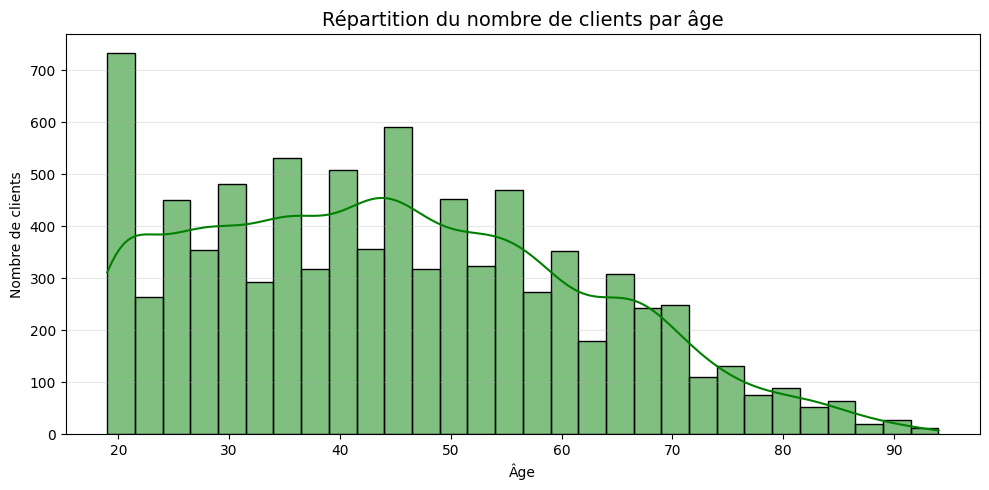

In [23]:
#Histogramme (le plus simple en terme de lecture pour les data présentes)


plt.figure(figsize=(10, 5))
sns.histplot(df_customers['age'], bins=30, kde=True, color='green')

plt.title("Répartition du nombre de clients par âge", fontsize=14)
plt.xlabel("Âge", fontsize=10)
plt.ylabel("Nombre de clients", fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

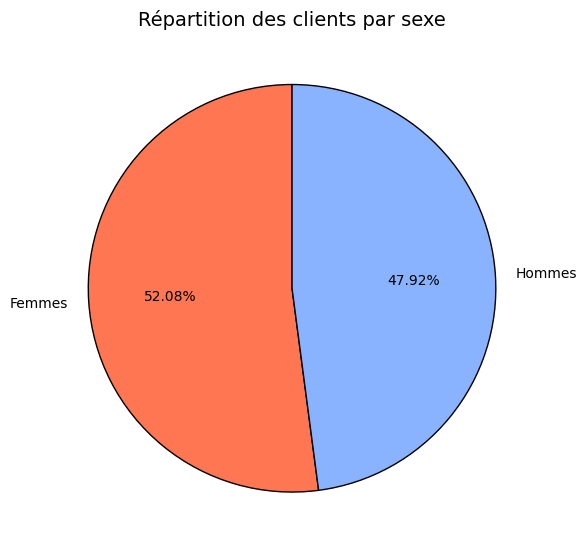

In [24]:
#Après répartition par l'âge, nous nous intéréssons à la répartition par genre (F & H)
#Graphique camembert pour la proportion :

repartition_sexe = df_customers['sex'].value_counts()

# Étiquettes avec % automatique
labels = ['Femmes', 'Hommes']
colors = ['#ff7653', '#89b3ff']

plt.figure(figsize=(6, 6))
plt.pie(
    repartition_sexe,
    labels=labels,
    autopct='%.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Répartition des clients par sexe", fontsize=14)
plt.tight_layout()
plt.show()


3. Structure et Jointure des fichiers pour construction du dataset final df_merge

Préparation des fichiers pour la jointure des données pour la table finale merged incluant products, transactions et customers.

Finalité : Permettre une étude plus détaillée des comportements et des profils clients.



In [25]:
#Jointure de products & Transactions
#Le but est d'analyser les ventes via les ID produits
#Identifier les produits dans le catalogues et le nombre de vente et également voir les clients qui ont fait peu et/.ou pas d'achats


In [26]:
df_prod_tx = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='left'
)

In [27]:
display(df_prod_tx.head())

print(f"Nombre de lignes après jointure Product & Transactions : {df_prod_tx.shape[0]}")
print("Aperçu des premières lignes :")

,id_prod,price,categ,date,session_id,client_id,year
0,0_1421,19.99,0,2021-03-01 04:13:00.107748,s_101,c_8533,2021.0
1,0_1421,19.99,0,2021-03-01 13:48:20.214075,s_285,c_5299,2021.0
2,0_1421,19.99,0,2021-03-01 15:07:42.730079,s_317,c_8024,2021.0
3,0_1421,19.99,0,2021-03-02 03:39:21.811833,s_563,c_7702,2021.0
4,0_1421,19.99,0,2021-03-02 19:09:41.789425,s_850,c_4057,2021.0


Nombre de lignes après jointure Product & Transactions : 687555
Aperçu des premières lignes :


In [28]:
#Vérification du nombre de produits identifiés (uniques)

print(f"Nombre de produits identifiés : {df_prod_tx['id_prod'].nunique()}")

Nombre de produits identifiés : 3286


In [29]:
#Croisement de données entre les transactions et les id_prod qui n'ont pas de match dans le dataset

df_tx_prod_check = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='right'
)

In [30]:
transactions_sans_produit = df_tx_prod_check[df_tx_prod_check['price'].isna()]

print(f"Nombre de transactions sans id_prod dans le dataset : {transactions_sans_produit.shape[0]}")
display(transactions_sans_produit[['id_prod', 'client_id', 'date', 'session_id']].head())


#On peux traduire que chaque transaction présente dans le dataset est bien relié à un produit du dataset product.csv

Nombre de transactions sans id_prod dans le dataset : 0


,id_prod,client_id,date,session_id


In [31]:
#Jointure avec CLIENT et même vérifications que pour transaction et products.
#Chercher les produits qui n'ont pas de transaction

In [32]:
#Jointure Produits et Transactions.csv
#vérification des produits dans le dataset


df_prod_tx = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='left'
)

print(f"Nombre de lignes après jointure avec products : {df_prod_tx.shape[0]}")
print("Aperçu des premières lignes :")
display(df_prod_tx.head())
print(f"Nombre de produits identifiés dans la base fusionnée : {df_prod_tx['id_prod'].nunique()}")

Nombre de lignes après jointure avec products : 687555
Aperçu des premières lignes :


,id_prod,price,categ,date,session_id,client_id,year
0,0_1421,19.99,0,2021-03-01 04:13:00.107748,s_101,c_8533,2021.0
1,0_1421,19.99,0,2021-03-01 13:48:20.214075,s_285,c_5299,2021.0
2,0_1421,19.99,0,2021-03-01 15:07:42.730079,s_317,c_8024,2021.0
3,0_1421,19.99,0,2021-03-02 03:39:21.811833,s_563,c_7702,2021.0
4,0_1421,19.99,0,2021-03-02 19:09:41.789425,s_850,c_4057,2021.0


Nombre de produits identifiés dans la base fusionnée : 3286


In [33]:
#Transaction ID avec un id_prod
#Vérification des produits dit "inconnus"

df_tx_prod_check = pd.merge(
    df_products,
    df_transactions,
    on='id_prod',
    how='right'
)


transactions_sans_produit = df_tx_prod_check[df_tx_prod_check['price'].isna()]


print(f"Nombre de transactions avec un id_prod absent : {transactions_sans_produit.shape[0]}")
display(transactions_sans_produit[['id_prod', 'client_id', 'date', 'session_id']].head())


#On constate que toutes les transactions possèdent un produit dans le dataset !!


Nombre de transactions avec un id_prod absent : 0


,id_prod,client_id,date,session_id


In [34]:
#Jointure externe avec le fichier customer.csv
#Clients + produits, incluant les produits n'ayant pas de transactions.

df_merged = pd.merge(
    df_customers[['client_id', 'sex', 'age']],
    df_prod_tx,
    on='client_id',
    how='outer'
)


print("Dimensions du Dataset final :", df_merged.shape)
print("\nAperçu des données fusionnées :")
display(df_merged.head())

Dimensions du Dataset final : (687576, 9)

Aperçu des données fusionnées :


,client_id,sex,age,id_prod,price,categ,date,session_id,year
0,c_1,m,68.0,0_513,11.99,0.0,2021-07-21 22:41:38.769525,s_65433,2021.0
1,c_1,m,68.0,0_513,11.99,0.0,2022-03-21 22:41:38.769525,s_182481,2022.0
2,c_1,m,68.0,0_513,11.99,0.0,2022-10-21 22:41:38.769525,s_286029,2022.0
3,c_1,m,68.0,0_513,11.99,0.0,2022-12-21 22:41:38.769525,s_315508,2022.0
4,c_1,m,68.0,1_433,18.99,1.0,2021-10-15 11:28:27.540834,s_105105,2021.0


In [35]:
print("Valeurs manquantes après jointure :")
print(df_merged.isnull().sum())

Valeurs manquantes après jointure :
client_id     21
sex           21
age           21
id_prod       21
price         21
categ         21
date          42
session_id    42
year          42
dtype: int64


In [36]:
#Vérification des clients présents dans le base de donnée mais n'ayant pas de transaction effectuée


nb_clients_inactifs = df_merged[df_merged['id_prod'].isna()]['client_id'].nunique()
print(f"Nombre de clients sans transactions : {nb_clients_inactifs}")

# Liste détaillée de ces clients
df_merged[df_merged['id_prod'].isna()]

Nombre de clients sans transactions : 21


,client_id,sex,age,id_prod,price,categ,date,session_id,year
18399,c_1223,m,60.0,NaN,NaN,NaN,NaT,NaN,NaN
167262,c_2706,f,56.0,NaN,NaN,NaN,NaT,NaN,NaN
191551,c_3017,f,31.0,NaN,NaN,NaN,NaT,NaN,NaN
225851,c_3443,m,64.0,NaN,NaN,NaN,NaT,NaN,NaN
240172,c_3526,m,67.0,NaN,NaN,NaN,NaT,NaN,NaN
261001,c_3789,f,26.0,NaN,NaN,NaN,NaT,NaN,NaN
282271,c_4086,f,31.0,NaN,NaN,NaN,NaT,NaN,NaN
305952,c_4358,m,24.0,NaN,NaN,NaN,NaT,NaN,NaN
309172,c_4406,f,25.0,NaN,NaN,NaN,NaT,NaN,NaN
312791,c_4447,m,67.0,NaN,NaN,NaN,NaT,NaN,NaN


In [37]:
#Même opération pour les produits qui n'ont aucune transaction

nb_produits_non_vendus = df_merged[df_merged['client_id'].isna()]['id_prod'].nunique()
print(f"Nombre de produits sans transactions : {nb_produits_non_vendus}")

# Liste détaillée avec toutes les colonnes disponibles
produits_non_vendus = df_merged[df_merged['client_id'].isna()].drop_duplicates(subset=['id_prod'])

display(produits_non_vendus)

Nombre de produits sans transactions : 21


,client_id,sex,age,id_prod,price,categ,date,session_id,year
687555,NaN,NaN,NaN,0_1016,35.06,0.0,NaT,NaN,NaN
687556,NaN,NaN,NaN,0_1780,1.67,0.0,NaT,NaN,NaN
687557,NaN,NaN,NaN,0_1062,20.08,0.0,NaT,NaN,NaN
687558,NaN,NaN,NaN,0_1119,2.99,0.0,NaT,NaN,NaN
687559,NaN,NaN,NaN,0_1014,1.15,0.0,NaT,NaN,NaN
687560,NaN,NaN,NaN,1_0,31.82,1.0,NaT,NaN,NaN
687561,NaN,NaN,NaN,0_1318,20.92,0.0,NaT,NaN,NaN
687562,NaN,NaN,NaN,0_1800,22.05,0.0,NaT,NaN,NaN
687563,NaN,NaN,NaN,0_1645,2.99,0.0,NaT,NaN,NaN
687564,NaN,NaN,NaN,0_322,2.99,0.0,NaT,NaN,NaN


In [38]:
#21 lignes absentes dans id_prod car ce sont des clients présents dans le dataset mais qui n'ont aucune transaction effectuée.
#21 Lignes absentes car ce sont des produits qui n'ont jamais été achetés par des clients (avec client_id)



4. Analyse du chiffre d'affaire


- Décomposition en moyenne mobiles de la série
- Courbe de Lorenz pour la dispersion des clients
- Et tout autre analyse complémentaire permettant une meilleure compréhension du business et ou des ventes en général+ Comportement client

# 4.1 Analyse globale

In [39]:
def fmt(n: float | int, decimals: int = 0) -> str:
    """Formate un nombre avec l'espace fine comme séparateur de milliers."""
    spec = f":,.{decimals}f"
    return format(n, spec.lstrip(":")).replace(",", "\u202f")


# ── Préparation des données ───────────────────────────────────────────────────

# On conserve uniquement les lignes avec un client ET un produit identifiés
# (les lignes incomplètes sont exclues du calcul du CA et des statistiques)
df_transactions_valides = df_merged[
    df_merged['client_id'].notna() & df_merged['id_prod'].notna()
]

# ── Chiffres globaux ──────────────────────────────────────────────────────────

print("Chiffres globaux")
print("-" * 40)

# Chiffre d'affaires
ca_total = df_transactions_valides['price'].sum()
print(f"Chiffre d'affaires total            : {fmt(ca_total, decimals=2)} €")

# Transactions
nb_transactions = df_transactions_valides.shape[0]
print(f"Nombre total de transactions        : {fmt(nb_transactions)}")

# Catalogue produits
taille_catalogue         = df_products['id_prod'].nunique()
nb_produits_vendus       = df_transactions_valides['id_prod'].nunique()
nb_produits_non_vendus   = taille_catalogue - nb_produits_vendus

print(f"Références au catalogue             : {fmt(taille_catalogue)}")
print(f"Références vendues                  : {fmt(nb_produits_vendus)}")
print(f"Références jamais achetées          : {fmt(nb_produits_non_vendus)}")

# Clients
nb_clients_total    = df_customers['client_id'].nunique()
nb_clients_actifs   = df_transactions_valides['client_id'].nunique()
nb_clients_inactifs = nb_clients_total - nb_clients_actifs

print(f"Clients avec au moins 1 transaction : {fmt(nb_clients_actifs)}")
print(f"Clients sans aucune transaction     : {fmt(nb_clients_inactifs)}")

Chiffres globaux
----------------------------------------
Chiffre d'affaires total            : 12 027 663.10 €
Nombre total de transactions        : 687 534
Références au catalogue             : 3 286
Références vendues                  : 3 265
Références jamais achetées          : 21
Clients avec au moins 1 transaction : 8 600
Clients sans aucune transaction     : 21


# 4.2. Analyse du CA

In [40]:
#Nous devrions d'abord isoler les ventes. (N'afficher que les transactions existantes)
#Puis mensualiser l'affichage des data pour afficher une évolution marquant les périodes importantes des ventes.


In [41]:
df_transactions_valides = df_merged[df_merged['client_id'].notna() & df_merged['id_prod'].notna()].copy()
df_transactions_valides['mois'] = df_transactions_valides['date'].dt.to_period('M').dt.to_timestamp()
ca_mensuel = df_transactions_valides.groupby('mois')['price'].sum().reset_index()

#Moyenne Mobile

ca_mensuel['CA_moyenne_mobile_3M'] = ca_mensuel['price'].rolling(window=3).mean()

display(ca_mensuel.head())


,mois,price,CA_moyenne_mobile_3M
0,2021-03-01,482440.61,NaN
1,2021-04-01,476109.30,NaN
2,2021-05-01,492943.47,483831.126667
3,2021-06-01,484088.56,484380.443333
4,2021-07-01,482835.40,486622.476667


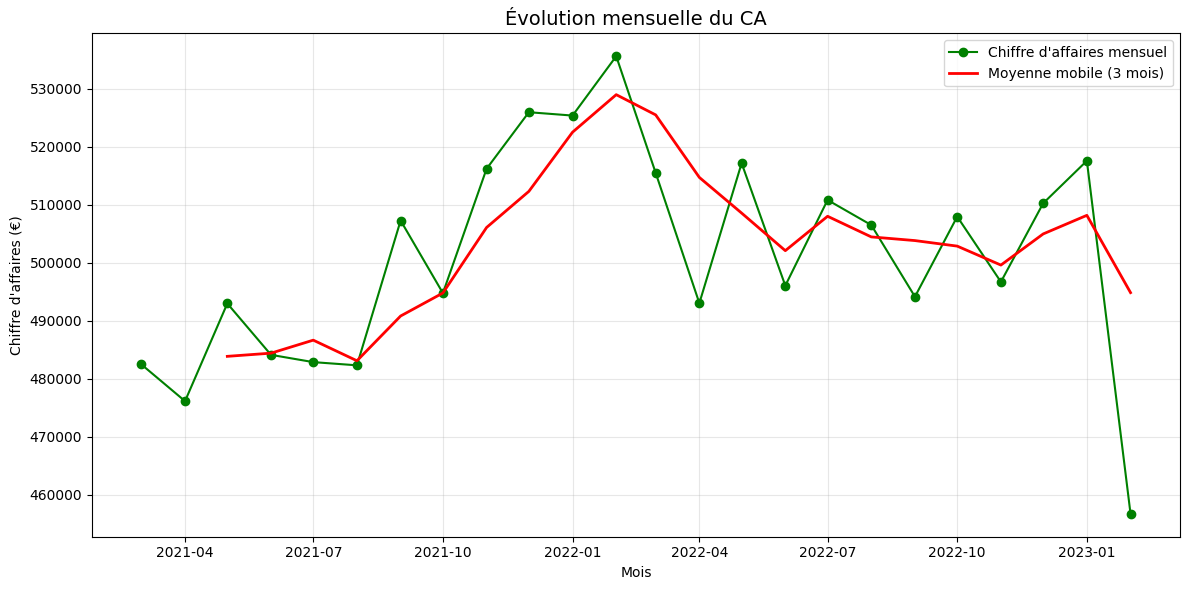

In [42]:
plt.figure(figsize=(12, 6))

# Courbe du chiffre d'affaires
plt.plot(ca_mensuel['mois'], ca_mensuel['price'], label="Chiffre d'affaires mensuel", color='green', marker='o')

# Courbe de la moyenne mobile
plt.plot(ca_mensuel['mois'], ca_mensuel['CA_moyenne_mobile_3M'], label="Moyenne mobile (3 mois)", color='red', linewidth=2)

plt.title("Évolution mensuelle du CA", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. CA par produits


*   CA par catégorie (0, 1 ou 2)



*   Graphique de répartition du CA par catégorie
*   Graphique de Volume de vente par catégoriee







In [43]:
# Répartition du CA par catégorie de produit (categ : 0, 1 ou 2)

ca_par_categ  = df_transactions_valides.groupby('categ')['price'].sum().sort_index()
pct_par_categ = (ca_par_categ / ca_par_categ.sum() * 100)

# Tableau récapitulatif : CA et part relative par catégorie
df_ca_categ = pd.DataFrame({
    "Chiffre d'affaires (€)" : ca_par_categ.apply(lambda x: fmt(x, decimals=2) + " €"),
"Part du CA (%)"         : pct_par_categ.apply(lambda x: fmt(x, decimals=2) + " %"),})

display(df_ca_categ)

,Chiffre d'affaires (€),Part du CA (%)
categ,,
0.0,4 419 730.97 €,36.75 %
1.0,4 827 657.11 €,40.14 %
2.0,2 780 275.02 €,23.12 %


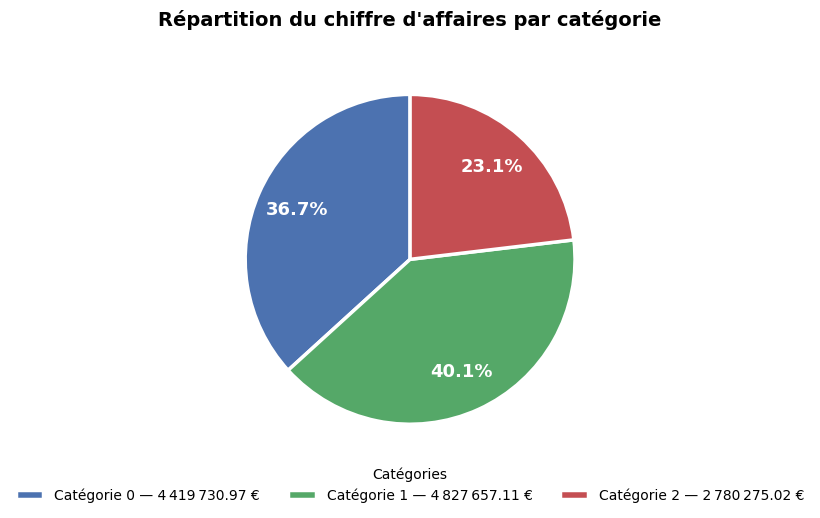

In [44]:
# Visualisation : répartition du CA par catégorie (camembert)

labels = [f"Catégorie {int(i)}" for i in ca_par_categ.index]

couleurs_categories = {
    0.0: '#4C72B0',
    1.0: '#55A868',
    2.0: '#C44E52'
}
colors = [couleurs_categories.get(i, '#999999') for i in ca_par_categ.index]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    ca_par_categ,
    labels=None,
    autopct='%.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    pctdistance=0.75,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax.legend(
    wedges,
    [f"{l} — {fmt(v, decimals=2)} €" for l, v in zip(labels, ca_par_categ)],
    title="Catégories",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    fontsize=10,
    frameon=False
)

ax.set_title("Répartition du chiffre d'affaires par catégorie",
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [45]:
# Nombre de produits vendus (volume) par catégorie
volume_par_categ = df_transactions_valides.groupby('categ')['id_prod'].count()

# CA par catégorie
ca_par_categ = df_transactions_valides.groupby('categ')['price'].sum()

# Prix moyen unitaire = CA / nombre de produits vendus
prix_moyen_categ = ca_par_categ / volume_par_categ

# Assemblage dans un nouveau DataFrame
df_volume_ca = pd.DataFrame({
    "Produits vendus (volume)" : volume_par_categ.apply(lambda x: fmt(x)),
    "Chiffre d'affaires (€)"  : ca_par_categ.apply(lambda x: fmt(x, decimals=2) + " €"),
    "Prix moyen (€)"          : prix_moyen_categ.apply(lambda x: fmt(x, decimals=2) + " €"),
})

display(df_volume_ca)

,Produits vendus (volume),Chiffre d'affaires (€),Prix moyen (€)
categ,,,
0.0,415 459,4 419 730.97 €,10.64 €
1.0,235 592,4 827 657.11 €,20.49 €
2.0,36 483,2 780 275.02 €,76.21 €


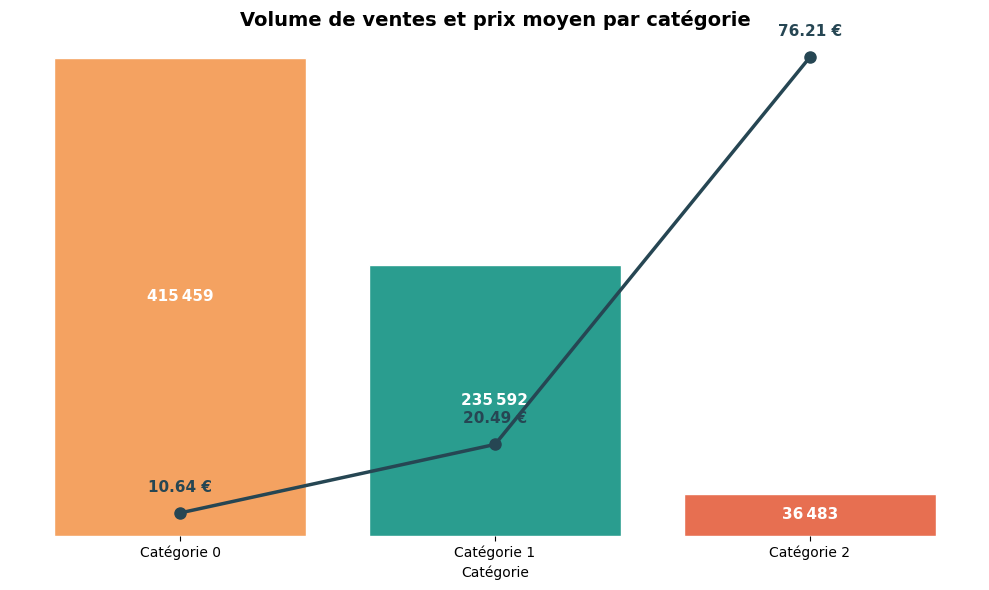

In [46]:
# Nouvelle palette
couleurs_categories = {
    0.0: '#F4A261',  # orange sable
    1.0: '#2A9D8F',  # vert canard
    2.0: '#E76F51'   # corail
}
colors_barres = [couleurs_categories.get(c, '#999999') for c in volume_par_categ.index]
labels_categ  = [f"Catégorie {int(i)}" for i in volume_par_categ.index]

fig, ax1 = plt.subplots(figsize=(10, 6))

# ── Barres : volume ───────────────────────────────────────────────────────────
bars = ax1.bar(labels_categ, volume_par_categ, color=colors_barres, edgecolor='white')

for bar, val in zip(bars, volume_par_categ):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
        fmt(val),
        ha='center', va='center',
        color='white', fontsize=11, fontweight='bold'
    )

ax1.set_title("Volume de ventes et prix moyen par catégorie", fontsize=14, fontweight='bold')
ax1.set_ylabel("")
ax1.set_yticks([])
ax1.set_xlabel("Catégorie")
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── Courbe : prix moyen ───────────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(labels_categ, prix_moyen_categ,
         color='#264653', linewidth=2.5, marker='o', markersize=8)

for i, val in enumerate(prix_moyen_categ):
    ax2.text(i, val + max(prix_moyen_categ) * 0.04,
             fmt(val, decimals=2) + " €",
             ha='center', fontsize=11, color='#264653', fontweight='bold')

ax2.set_ylabel("")
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# 5.2 -  Nombre de clients par mois (Brief)

In [47]:
# Nombre de clients uniques par mois
clients_actifs_par_mois = df_transactions_valides.groupby('mois')['client_id'].nunique().reset_index()
clients_actifs_par_mois.rename(columns={'client_id': 'clients_uniques'}, inplace=True)
display(clients_actifs_par_mois.head())

,mois,clients_uniques
0,2021-03-01,5676
1,2021-04-01,5674
2,2021-05-01,5644
3,2021-06-01,5659
4,2021-07-01,5672


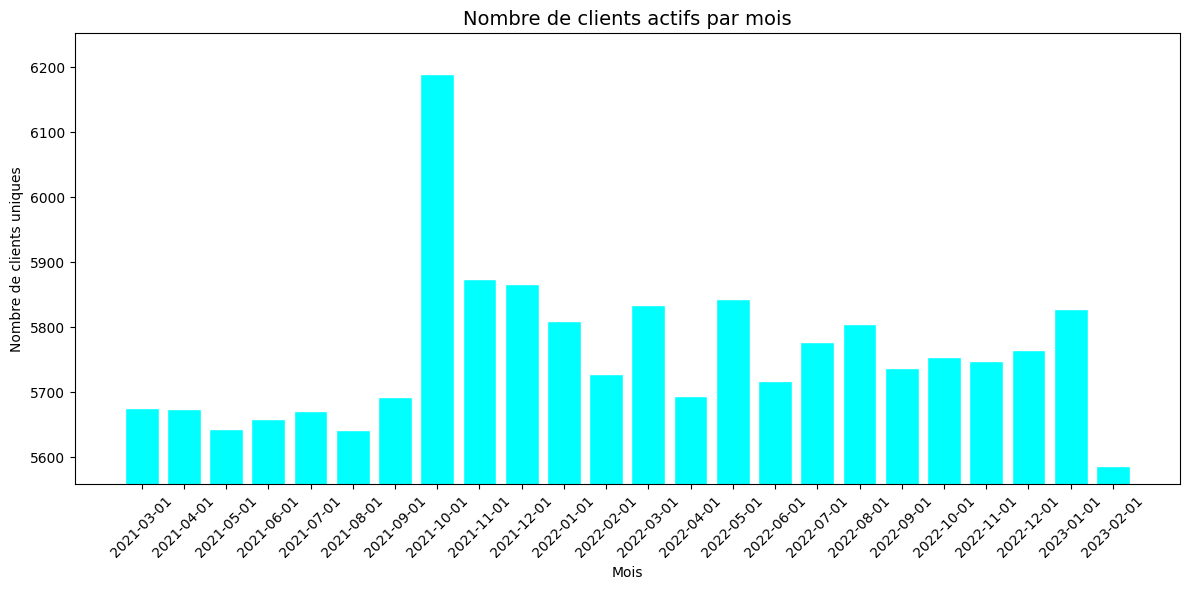

In [48]:
plt.figure(figsize=(12, 6))

plt.bar(
    clients_actifs_par_mois['mois'].astype(str),
    clients_actifs_par_mois['clients_uniques'],
    color='cyan',
    edgecolor='white'
)

plt.title("Nombre de clients actifs par mois", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Nombre de clients uniques")
plt.xticks(rotation=45)


val_min = clients_actifs_par_mois['clients_uniques'].min()
val_max = clients_actifs_par_mois['clients_uniques'].max()
plt.ylim(val_min * 0.995, val_max * 1.01)

plt.tight_layout()
plt.show()

# 5.3 - Nombre de transactions et graphique

In [49]:
#Nombre de transactions (Brief)

transactions_sessions_par_mois = df_transactions_valides.groupby('mois').agg({
    'id_prod': 'count',
    'session_id': pd.Series.nunique
}).reset_index()

transactions_sessions_par_mois.rename(columns={
    'id_prod': 'transactions',
    'session_id': 'sessions_uniques'
}, inplace=True)

display(transactions_sessions_par_mois.head())


,mois,transactions,sessions_uniques
0,2021-03-01,28601,14201
1,2021-04-01,28443,13970
2,2021-05-01,28285,14168
3,2021-06-01,26850,13838
4,2021-07-01,24738,13571


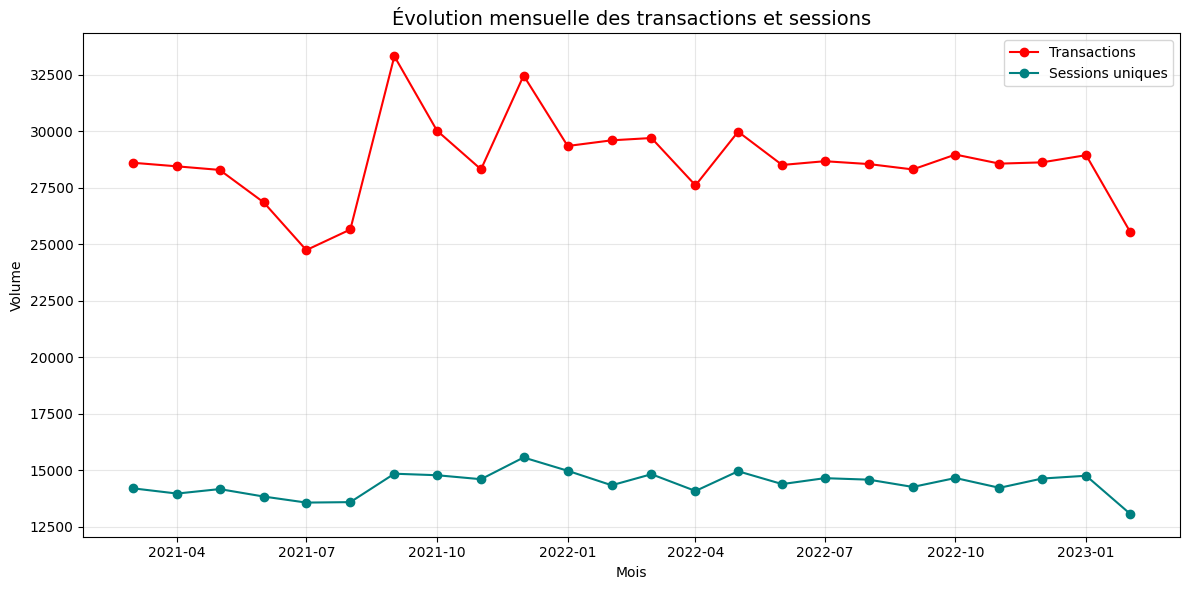

In [50]:
plt.figure(figsize=(12, 6))

# Transactions (produits vendus)
plt.plot(transactions_sessions_par_mois['mois'], transactions_sessions_par_mois['transactions'],
         label='Transactions', color='red', marker='o')

# Sessions
plt.plot(transactions_sessions_par_mois['mois'], transactions_sessions_par_mois['sessions_uniques'],
         label='Sessions uniques', color='teal', marker='o')

plt.title("Évolution mensuelle des transactions et sessions", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
#Nombre de produits par sessions d'achat (en moyenne)

transactions_sessions_par_mois['produits_par_session'] = (
    transactions_sessions_par_mois['transactions'] / transactions_sessions_par_mois['sessions_uniques']
).round(2)
display(transactions_sessions_par_mois[['mois', 'transactions', 'sessions_uniques', 'produits_par_session']].head())

,mois,transactions,sessions_uniques,produits_par_session
0,2021-03-01,28601,14201,2.01
1,2021-04-01,28443,13970,2.04
2,2021-05-01,28285,14168,2.00
3,2021-06-01,26850,13838,1.94
4,2021-07-01,24738,13571,1.82


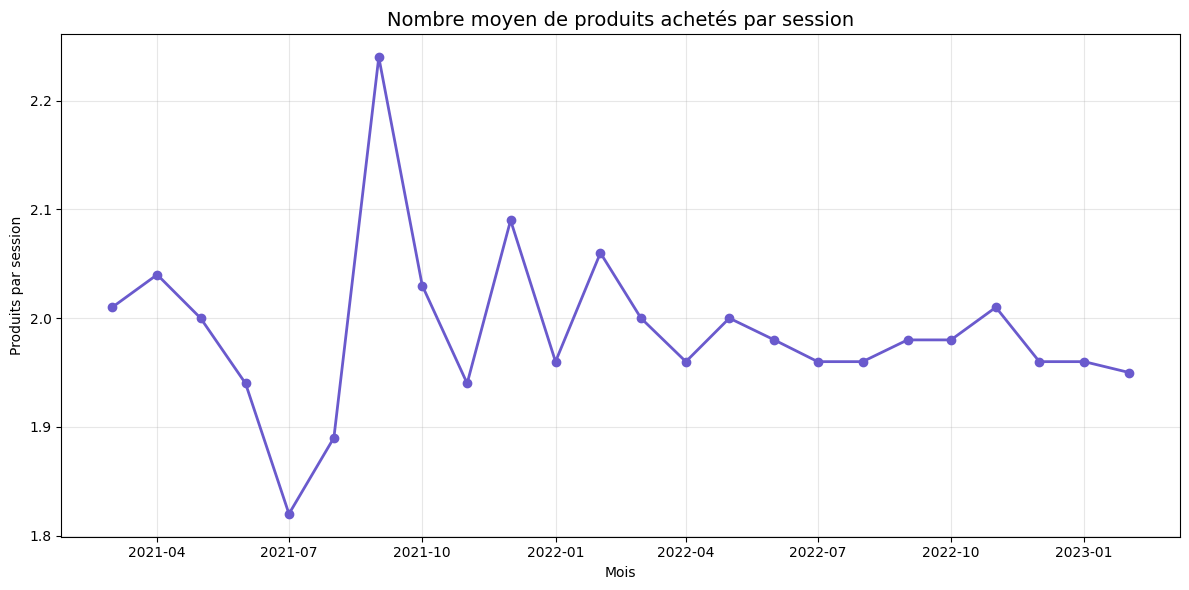

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(
    transactions_sessions_par_mois['mois'],
    transactions_sessions_par_mois['produits_par_session'],
    marker='o', color='slateblue', linewidth=2
)

plt.title("Nombre moyen de produits achetés par session", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Produits par session")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.4 - TOP ET FLOPS (Brief)

In [53]:
#Nombre de vente par produit unique

top_produits = df_transactions_valides['id_prod'].value_counts().head(10).reset_index()
top_produits.columns = ['id_prod', 'nb_ventes']
display(top_produits)

,id_prod,nb_ventes
0,1_369,2340
1,1_417,2269
2,1_414,2246
3,1_498,2202
4,1_425,2163
5,1_403,2040
6,1_413,2036
7,1_412,2014
8,1_406,2003
9,1_407,2001


In [54]:
#Outliers les moins vendus (<2)

vente_par_produit = df_transactions_valides['id_prod'].value_counts()
flops = vente_par_produit[vente_par_produit <= 2].reset_index()
flops.columns = ['id_prod', 'nb_ventes']
print(f"Nombre de produits vendus au maximum 2 fois : {flops.shape[0]}")
display(flops.head(10))

Nombre de produits vendus au maximum 2 fois : 44


,id_prod,nb_ventes
0,0_495,2
1,0_1279,2
2,2_93,2
3,1_402,2
4,0_980,2
5,0_1576,2
6,2_77,2
7,0_1544,2
8,0_1840,2
9,0_1653,2


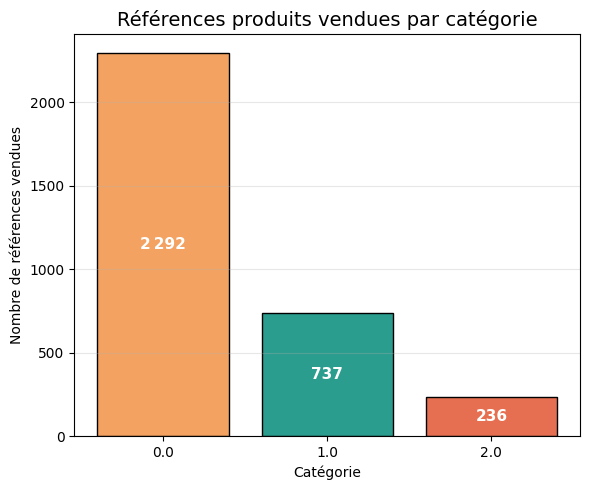

In [55]:
#Recherche par catégorie des produits vendus
#Changer le float pour les catégories

refs_vendus = df_transactions_valides[['id_prod', 'categ']].drop_duplicates()
refs_par_categ = refs_vendus['categ'].value_counts().sort_index()
colors_barres = [couleurs_categories.get(categ, 'blue') for categ in refs_par_categ.index]

#Graphique de visualisation

plt.figure(figsize=(6, 5))
bars = plt.bar(
    refs_par_categ.index.astype(str),
    refs_par_categ.values,
    color=colors_barres,
    edgecolor='black'
)

for i, val in enumerate(refs_par_categ.values):
    plt.text(
        i,
        val / 2,
        f"{val:,}".replace(",", "\u202f"),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

plt.title("Références produits vendues par catégorie", fontsize=14)
plt.xlabel("Catégorie")
plt.ylabel("Nombre de références vendues")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 5.5 - Recherche des clients BTOB

In [56]:
#Recherche de clients BtoB par le nombre de transactions le plus élevées

top_clients = df_transactions_valides['client_id'].value_counts().head(10).reset_index()
top_clients.columns = ['client_id', 'nb_ventes']

display(top_clients)

,client_id,nb_ventes
0,c_1609,25586
1,c_6714,9199
2,c_3454,6793
3,c_4958,5222
4,c_2140,405
5,c_3263,403
6,c_2595,398
7,c_2077,386
8,c_1637,384
9,c_7421,381


In [57]:
#Isolation des 4 plus gros clients par nombre de transactions
#Chiffre d'affaire par ces clients et part du CA total en proportion %


clients_b2b_potentiels = top_clients['client_id'].head(4).tolist()
ca_b2b = df_transactions_valides[df_transactions_valides['client_id'].isin(clients_b2b_potentiels)]['price'].sum()
ca_total = df_transactions_valides['price'].sum()
part_b2b = round((ca_b2b / ca_total) * 100, 2)

print(f"Chiffre d'affaires estimé BtoB : {ca_b2b:,.2f} €".replace(",", "\u202f"))
print(f"Part du CA total : {part_b2b:.2f} %")

Chiffre d'affaires estimé BtoB : 884 296.09 €
Part du CA total : 7.35 %


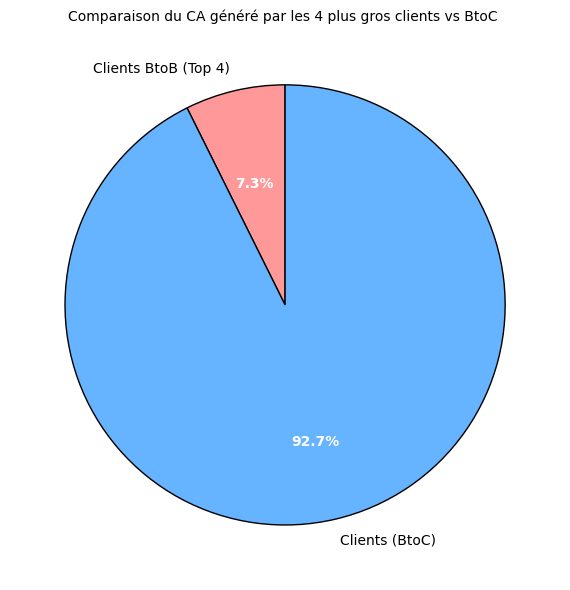

In [58]:
#Comparaison du CA entre clients BtoB et BtoC
labels = ['Clients BtoB (Top 4)', 'Clients (BtoC)']
sizes = [part_b2b, 100 - part_b2b]
colors = ['#ff9999', '#66b3ff']


def make_autopct(values):
    def my_autopct(pct):
        return f"\n{pct:.1f}%" if pct > 0 else ''
    return my_autopct

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=make_autopct(sizes),
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("Comparaison du CA généré par les 4 plus gros clients vs BtoC ", fontsize=10)
plt.tight_layout()
plt.show()

# 5.6 - Courbe de Lorenz pour la répartition du CA

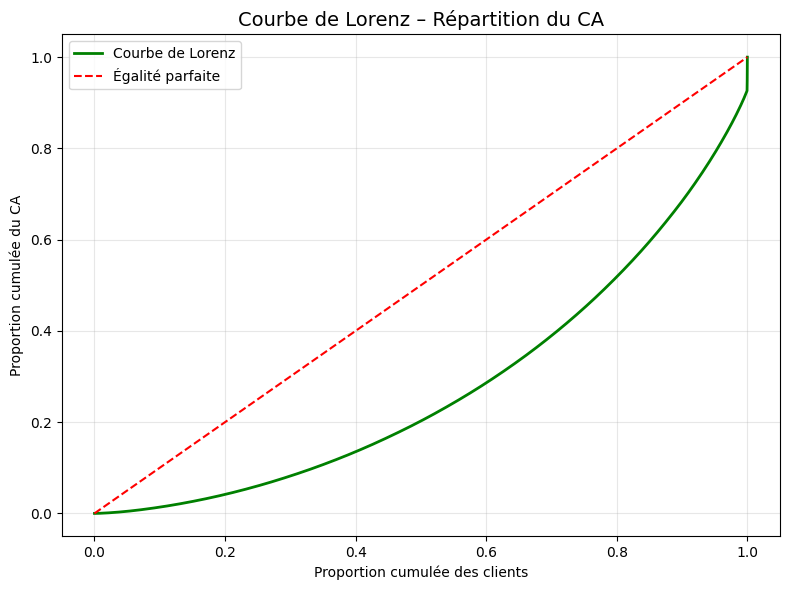

In [59]:
#Courbe de Lorenz (Brief) 20-80

ca_par_client = df_transactions_valides.groupby('client_id')['price'].sum().sort_values().reset_index()


ca_par_client['cum_clients'] = (np.arange(1, len(ca_par_client) + 1)) / len(ca_par_client)
ca_par_client['cum_ca'] = ca_par_client['price'].cumsum() / ca_par_client['price'].sum()

plt.figure(figsize=(8, 6))
plt.plot(ca_par_client['cum_clients'], ca_par_client['cum_ca'], label="Courbe de Lorenz", color='green', linewidth=2)
plt.plot([0, 1], [0, 1], label="Égalité parfaite", linestyle='--', color='red')

plt.title("Courbe de Lorenz – Répartition du CA", fontsize=14)
plt.xlabel("Proportion cumulée des clients")
plt.ylabel("Proportion cumulée du CA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
#Indice de GINI : (array non négatif)
#Proche de 0 = clients contribuent au CA et si on se rapproche de 1 = Seul quelques clients contribuent au CA

#Ici on voit bien que 0,44 = partie faible de clients contribuent à une bonne partie du CA réalisé
#Rappel les chiffres précédents avec 7,3% du CA réalisé par les clients BtoB



def gini(array):
    """Calcul de l’indice de Gini"""
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array)) / (n * np.sum(array)) - (n + 1) / n

# Application au chiffre d'affaires par client

gini_index = gini(ca_par_client['price'].values)

print(f"Indice de Gini du CA client : {gini_index:.4f}")

Indice de Gini du CA client : 0.4419


In [61]:
#Indice de Gini pour les clients BtoC

clients_b2b_potentiels = top_clients['client_id'].head(4).tolist()
df_b2c = df_transactions_valides[~df_transactions_valides['client_id'].isin(clients_b2b_potentiels)].copy()
ca_par_client_b2c = df_b2c.groupby('client_id')['price'].sum().sort_values().reset_index()
ca_par_client_b2c['cum_clients'] = (np.arange(1, len(ca_par_client_b2c) + 1)) / len(ca_par_client_b2c)
ca_par_client_b2c['cum_ca'] = ca_par_client_b2c['price'].cumsum() / ca_par_client_b2c['price'].sum()
gini_b2c = 1 - 2 * np.trapz(ca_par_client_b2c['cum_ca'], ca_par_client_b2c['cum_clients'])
print(f"Indice de Gini B2C : {gini_b2c:.4f}")


Indice de Gini B2C : 0.3983


/tmp/ipykernel_3584/1967436578.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini_b2c = 1 - 2 * np.trapz(ca_par_client_b2c['cum_ca'], ca_par_client_b2c['cum_clients'])


6. Analyse des comportements clients (qualitatives et quantitatives)







1.   Courbe de Lorenz
2.   Spearman
3. Heatmap
4. khi2


In [62]:
#Heatmap et corrélation entre le genre et la catégorie d'achat des clients

df_genre_categ = df_b2c[['client_id', 'sex', 'categ']].dropna()
table_contingence = pd.crosstab(df_genre_categ['sex'], df_genre_categ['categ'])
table_contingence

categ,0.0,1.0,2.0
sex,,,
f,200793,115721,16980
m,186488,104884,15868


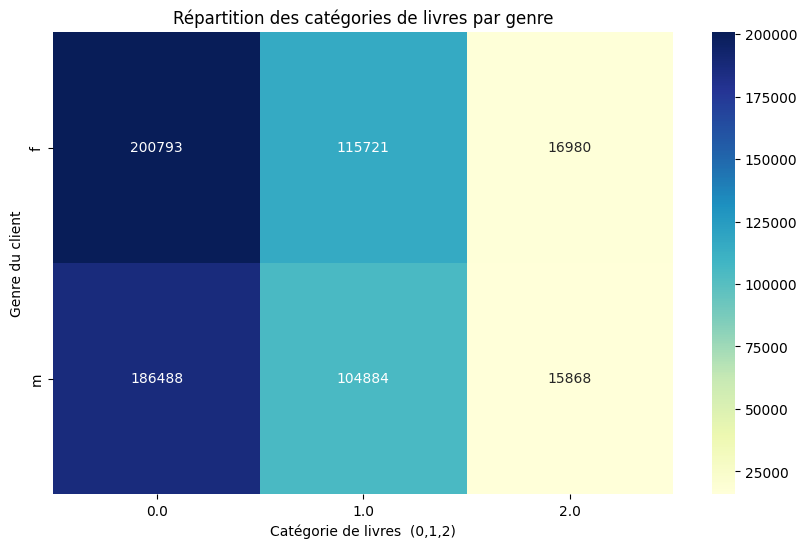

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(table_contingence, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Répartition des catégories de livres par genre")
plt.xlabel("Catégorie de livres  (0,1,2)")
plt.ylabel("Genre du client")
plt.show()

In [64]:
#Test Khi2

from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(table_contingence)

print(f"Statistique Chi-2: {chi2_stat:.2f}")
print(f"Valeur p: {p_value:.8f}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

if p_value < 0.05:
    print("Il existe une association significative entre le genre et la catégorie de livres achetés.")
else:
    print("Aucune association significative détectée entre le genre et la catégorie de livres achetés.")

    #On remarque une corrélation significative entre le genre et la catégorie achetée par les clients

Statistique Chi-2: 22.67
Valeur p: 0.00001196
Degrés de liberté: 2
Fréquences attendues:
[[201574.89662481 114822.13191434  17096.97146086]
 [185706.10337519 105782.86808566  15751.02853914]]
Il existe une association significative entre le genre et la catégorie de livres achetés.


# 6.2 - Spearman & Pearson

In [65]:
#Montant total des achats (par clients en €)

df_total_achats = df_b2c.groupby('client_id', as_index=False)['price'].sum()
df_total_achats.rename(columns={'price': 'montant_total_achats'}, inplace=True)
df_total_achats.head()


,client_id,montant_total_achats
0,c_1,629.02
1,c_10,1353.60
2,c_100,254.85
3,c_1000,2291.88
4,c_1001,1823.85


In [66]:
#Croisement avec l'âge des clients

df_age = df_b2c[['client_id', 'age']].drop_duplicates()
df_age_achats = pd.merge(df_total_achats, df_age, on='client_id')
df_age_achats.head()

,client_id,montant_total_achats,age
0,c_1,629.02,68.0
1,c_10,1353.60,67.0
2,c_100,254.85,31.0
3,c_1000,2291.88,57.0
4,c_1001,1823.85,41.0


Moyenne totale des achats : 1296.34 €
Écart-type standart en : 958.40 €


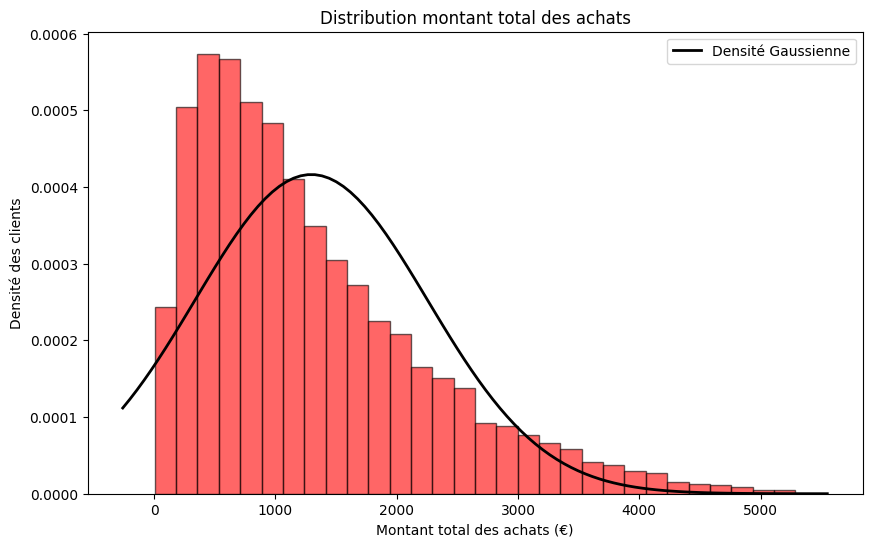

In [67]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

montants = df_age_achats['montant_total_achats'].dropna()

# Calcul de la moyenne et de l'écart-type
mean_montant = montants.mean()
std_montant = montants.std()

print(f"Moyenne totale des achats : {mean_montant:.2f} €")
print(f"Écart-type standart en : {std_montant:.2f} €")

# Tracé de l'histogramme avec densité
plt.figure(figsize=(10, 6))

# Histogramme
plt.hist(montants, bins=30, density=True, color='red', edgecolor='black', alpha=0.6)

mu, std = norm.fit(montants)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2, label='Densité Gaussienne')


plt.title('Distribution montant total des achats')
plt.xlabel('Montant total des achats (€)')
plt.ylabel('Densité des clients')
plt.legend()

plt.show()

In [68]:
#Test Spearman =

from scipy.stats import spearmanr
spearman_coef, spearman_p = spearmanr(df_age_achats['age'], df_age_achats['montant_total_achats'])
print(f"Coefficient de Spearman : {spearman_coef:.4f}")
print(f"Valeur p : {spearman_p:.12f}")

#Catégorisation

if spearman_p < 0.05:
    print("Corrélation significative entre l'âge et le montant total des achats (Spearman).")
else:
    print("Aucune corrélation significative détectée entre l'âge et le montant total des achats.")

Coefficient de Spearman : -0.1845
Valeur p : 0.000000000000
Corrélation significative entre l'âge et le montant total des achats (Spearman).


In [69]:
#Scatterplot de représentation =

import matplotlib.pyplot as plt
import seaborn as sns

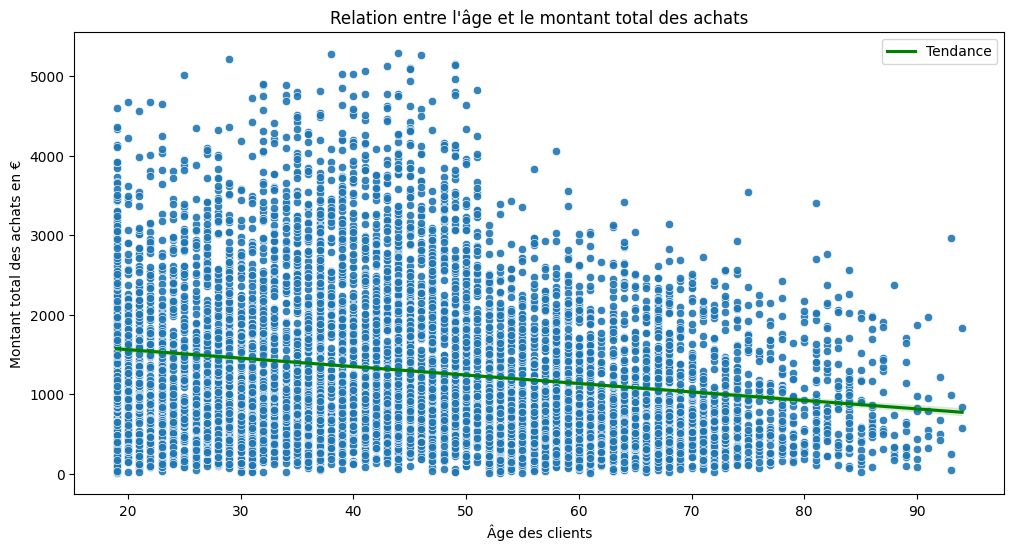

In [70]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_age_achats, x='age', y='montant_total_achats', alpha=0.9)

sns.regplot(
    data=df_age_achats,
    x='age',
    y='montant_total_achats',
    scatter=False,
    color='green',
    label='Tendance'
)

plt.title("Relation entre l'âge et le montant total des achats")
plt.xlabel("Âge des clients")
plt.ylabel("Montant total des achats en €")
plt.legend()

plt.show()

# 6.3 Données Quantitavatives

In [71]:
#Recherche complémentaire sur la fréquence d'achat par client

df_freq = df_b2c.groupby('client_id', as_index=False).agg(frequence_achat=('session_id', 'count'))
df_age_freq = df_b2c[['client_id', 'age']].drop_duplicates().merge(df_freq, on='client_id')
df_age_freq.head()

,client_id,age,frequence_achat
0,c_1,68.0,43
1,c_10,67.0,58
2,c_100,31.0,8
3,c_1000,57.0,126
4,c_1001,41.0,103


Moyenne de la fréquence : 74.54
Écart-type : 68.07


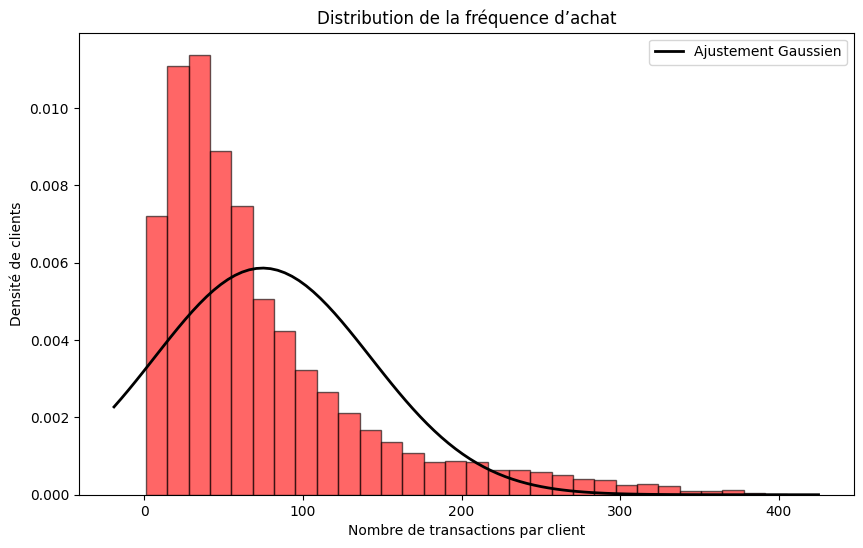

In [72]:
#Diagramme de représentation de la fréquence d'achat

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


frequences = df_age_freq['frequence_achat'].dropna()

mean_freq = frequences.mean()
std_freq = frequences.std()

print(f"Moyenne de la fréquence : {mean_freq:.2f}")
print(f"Écart-type : {std_freq:.2f}")

# Tracé de l'histogramme + courbe de Gauss
plt.figure(figsize=(10, 6))
plt.hist(frequences, bins=30, density=True, color='red', edgecolor='black', alpha=0.6)

# Ajustement Gaussien

mu, std = norm.fit(frequences)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Courbe Gaussienne

plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')
plt.title("Distribution de la fréquence d’achat")
plt.xlabel("Nombre de transactions par client")
plt.ylabel("Densité de clients")
plt.legend()

plt.show()


In [73]:
#Même schéma que précédemment avec Spearman

from scipy.stats import spearmanr

coef_spearman, p_spearman = spearmanr(df_age_freq['age'], df_age_freq['frequence_achat'])

print(f"Coefficient de Spearman (ρ) : {coef_spearman:.4f}")
print(f"Valeur p : {p_spearman:.6f}")

if p_spearman < 0.05:
    print("Corrélation significative entre l'âge et la fréquence d'achat.")
else:
    print("Aucune corrélation significative détectée entre l'âge et la fréquence d'achat.")

Coefficient de Spearman (ρ) : 0.1277
Valeur p : 0.000000
Corrélation significative entre l'âge et la fréquence d'achat.


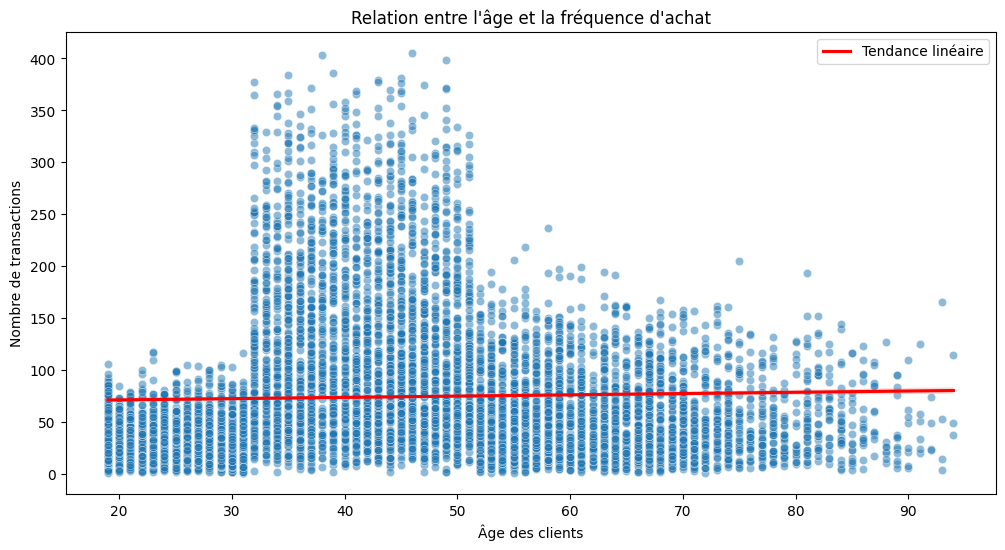

In [74]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_age_freq, x='age', y='frequence_achat', alpha=0.5)
sns.regplot(
    data=df_age_freq,
    x='age',
    y='frequence_achat',
    scatter=False,
    color='red',
    label='Tendance linéaire'
)
plt.title("Relation entre l'âge et la fréquence d'achat")
plt.xlabel("Âge des clients")
plt.ylabel("Nombre de transactions")
plt.legend()
plt.show()

In [75]:
#Etude sur l'âge et la valeur du panier moyen d'un client

df_total = df_b2c.groupby('client_id', as_index=False)['price'].sum()
df_total.rename(columns={'price': 'montant_total_achats'}, inplace=True)

df_freq = df_b2c.groupby('client_id', as_index=False)['session_id'].count()
df_freq.rename(columns={'session_id': 'frequence_achat'}, inplace=True)

df_panier = df_total.merge(df_freq, on='client_id')

df_panier['panier_moyen'] = df_panier['montant_total_achats'] / df_panier['frequence_achat']

df_age = df_b2c[['client_id', 'age']].drop_duplicates()
df_age_panier = df_panier.merge(df_age, on='client_id')

df_age_panier.head()

,client_id,montant_total_achats,frequence_achat,panier_moyen,age
0,c_1,629.02,43,14.628372,68.0
1,c_10,1353.60,58,23.337931,67.0
2,c_100,254.85,8,31.856250,31.0
3,c_1000,2291.88,126,18.189524,57.0
4,c_1001,1823.85,103,17.707282,41.0


Moyenne du panier moyen : 21.93 €
Écart-type : 14.63 €


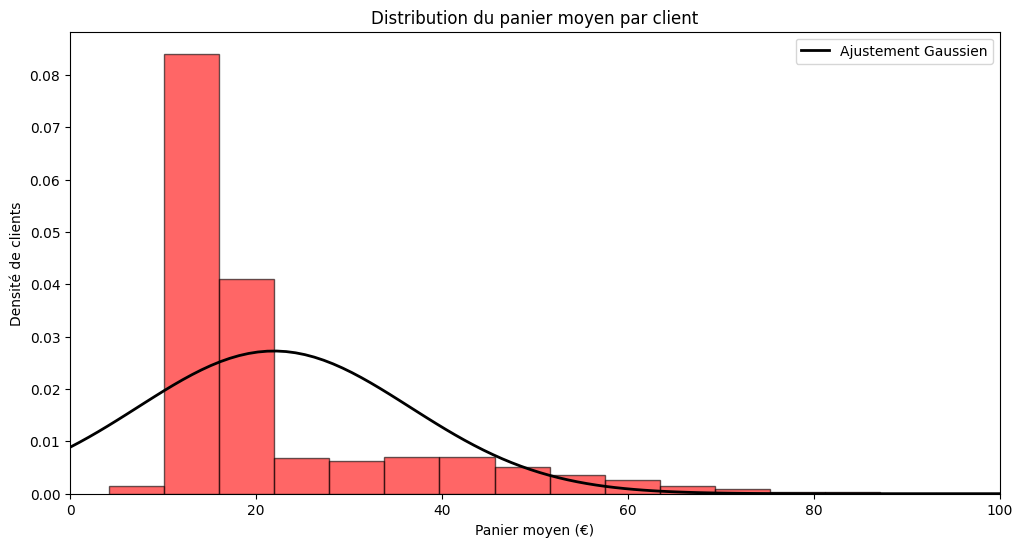

In [76]:
#Même schéma que précédemment :

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Récupérer la variable à analyser
paniers = df_age_panier['panier_moyen'].dropna()

# Statistiques descriptives
mean_panier = paniers.mean()
std_panier = paniers.std()

print(f"Moyenne du panier moyen : {mean_panier:.2f} €")
print(f"Écart-type : {std_panier:.2f} €")

# Tracé de l'histogramme
plt.figure(figsize=(12, 6))

# Histogramme
plt.hist(paniers, bins=30, density=True, color='red', edgecolor='black', alpha=0.6)

mu, std = norm.fit(paniers)
x = np.linspace(0, 100, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')
plt.title("Distribution du panier moyen par client")
plt.xlabel("Panier moyen (€)")
plt.ylabel("Densité de clients")
plt.xlim(0, 100)
plt.legend()

plt.show()

In [77]:
#Test Spearman :

coef_spearman, p_spearman = spearmanr(df_age_panier['age'], df_age_panier['panier_moyen'])
print(f"Coefficient de Spearman (ρ) : {coef_spearman:.4f}")
print(f"Valeur p : {p_spearman:.6f}")

if p_spearman < 0.05:
    print("Corrélation significative entre l'âge et le panier moyen.")
else:
    print("Aucune corrélation significative détectée entre l'âge et le panier moyen.")

Coefficient de Spearman (ρ) : -0.3259
Valeur p : 0.000000
Corrélation significative entre l'âge et le panier moyen.


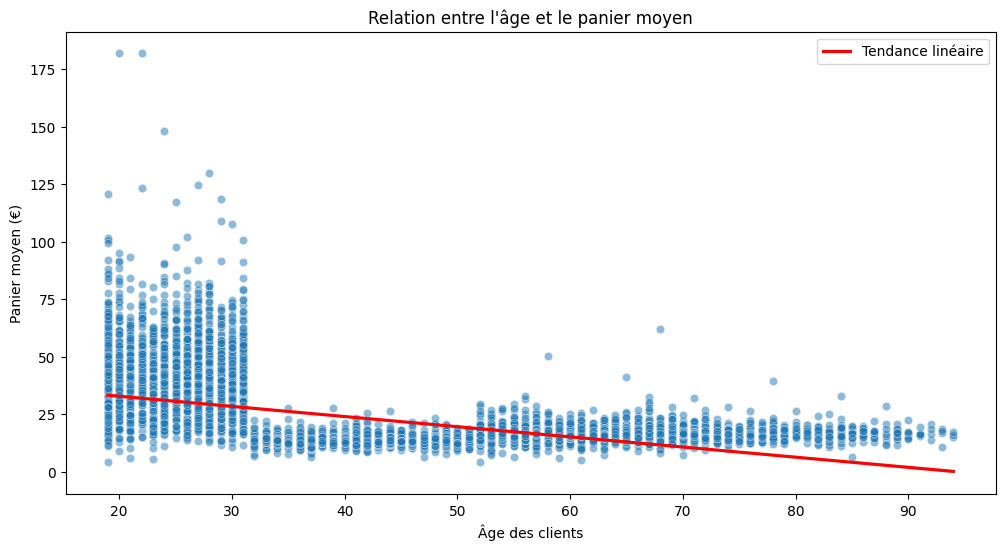

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_age_panier, x='age', y='panier_moyen', alpha=0.5)

sns.regplot(
    data=df_age_panier,
    x='age',
    y='panier_moyen',
    scatter=False,
    color='red',
    label='Tendance linéaire'
)

plt.title("Relation entre l'âge et le panier moyen")
plt.xlabel("Âge des clients")
plt.ylabel("Panier moyen (€)")
plt.legend()
plt.show()

In [79]:
#Recherche de corrélation entre la catégorie de livres achetés et l'âge des clients

df_categ_counts = df_b2c.groupby(['client_id', 'categ'], as_index=False).size()
df_categ_counts.rename(columns={'size': 'nb_achats'}, inplace=True)
df_categ_dominante = df_categ_counts.sort_values('nb_achats', ascending=False).drop_duplicates('client_id')
df_categ_dominante.rename(columns={'categ': 'categorie_dominante'}, inplace=True)
df_age = df_b2c[['client_id', 'age']].drop_duplicates()
df_age_categ = df_categ_dominante.merge(df_age, on='client_id')


df_age_categ.head()

,client_id,categorie_dominante,nb_achats,age
0,c_1637,0.0,316,35.0
1,c_3263,0.0,314,38.0
2,c_5953,0.0,311,37.0
3,c_2140,0.0,310,46.0
4,c_2595,0.0,307,49.0


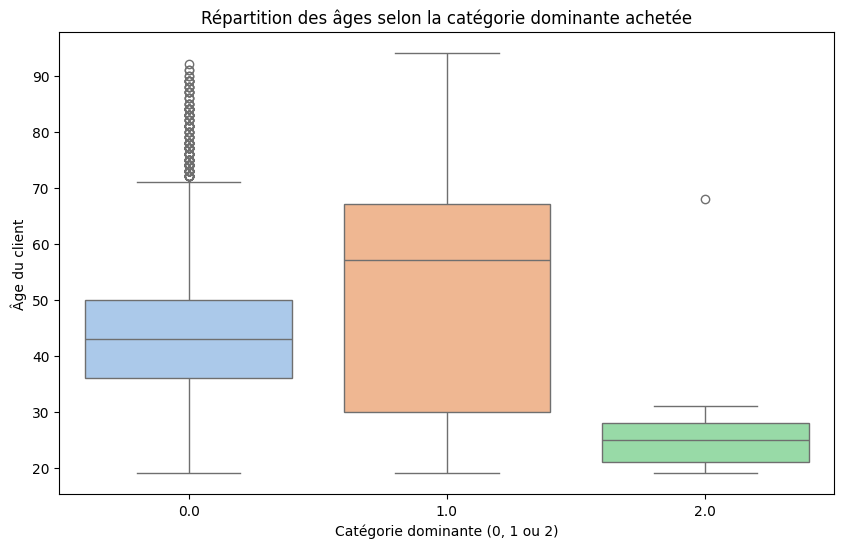

In [80]:
#Boxplot simple

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_age_categ,
    x='categorie_dominante',
    y='age',
    hue='categorie_dominante',
    palette='pastel',
    dodge=False,
    legend=False
)
plt.title("Répartition des âges selon la catégorie dominante achetée")
plt.xlabel("Catégorie dominante (0, 1 ou 2)")
plt.ylabel("Âge du client")
plt.show()

In [81]:
from scipy.stats import shapiro

resultats_shapiro = {}

for cat in sorted(df_age_categ['categorie_dominante'].unique()):
    ages_groupe = df_age_categ[df_age_categ['categorie_dominante'] == cat]['age'].dropna()

    if len(ages_groupe) > 5000:
        ages_groupe = ages_groupe.sample(5000, random_state=42)

    stat, p_value = shapiro(ages_groupe)

    resultats_shapiro[cat] = {
        'statistique': round(stat, 4),
        'p_value': round(p_value, 6),
        'normalite': 'Non normale' if p_value < 0.05 else 'Normale'
    }

# Affichage des résultats
for cat, res in resultats_shapiro.items():
    print(f"Catégorie {cat} :")
    print(f"  Statistique de Shapiro-Wilk : {res['statistique']}")
    print(f"  Valeur p : {res['p_value']}")
    print(f"  → {res['normalite']}\n")

Catégorie 0.0 :
  Statistique de Shapiro-Wilk : 0.9528
  Valeur p : 0.0
  → Non normale

Catégorie 1.0 :
  Statistique de Shapiro-Wilk : 0.911
  Valeur p : 0.0
  → Non normale

Catégorie 2.0 :
  Statistique de Shapiro-Wilk : 0.8787
  Valeur p : 0.0
  → Non normale



In [82]:
from scipy.stats import kruskal

# Extraction des âges par groupe
ages_cat_0 = df_age_categ[df_age_categ['categorie_dominante'] == 0]['age']
ages_cat_1 = df_age_categ[df_age_categ['categorie_dominante'] == 1]['age']
ages_cat_2 = df_age_categ[df_age_categ['categorie_dominante'] == 2]['age']

# Appliquer le test de Kruskal-Wallis
stat_kruskal, p_kruskal = kruskal(ages_cat_0, ages_cat_1, ages_cat_2)

# Affichage des résultats
print(f"Statistique de Kruskal-Wallis : {stat_kruskal:.4f}")
print(f"Valeur p : {p_kruskal:.6f}")

if p_kruskal < 0.05:
    print("Il existe une différence significative d'âge entre au moins deux groupes.")
else:
    print("Aucune différence significative détectée entre les groupes.")

Statistique de Kruskal-Wallis : 2172.5861
Valeur p : 0.000000
Il existe une différence significative d'âge entre au moins deux groupes.
